In [25]:
import sys
# Use an absolute path or relative path to the directory
sys.path.append("scripts")

import numpy as np
import pdb_voxelizier
import cnn_mlp_encoder
import jw_quantum_mapper
from scipy.optimize import minimize
from scipy.spatial.distance import squareform
from scipy.linalg import eigh
import sympy
import openfermion as op
import torch
import qiskit
import qiskit_algorithms
import qiskit_aer as q_aer
import qiskit_nature

In [2]:
num_sites = 6
tensor = pdb_voxelizier.pdb_to_tensor('proteins/1ENH.pdb')
coefficients = cnn_mlp_encoder.get_hamiltonian(tensor, num_qubits=num_sites)
qubit_instructions = jw_quantum_mapper.apply_jw(coefficients,num_sites=num_sites)


In [3]:
# View instructions by uncommenting this
jw_quantum_mapper.display_instructions(qubit_instructions)

--- QUANTUM HARDWARE INSTRUCTIONS ---
-0.0415 * Z0
-0.0177 * Z1
0.0083 * Z2
-0.0118 * Z3
-0.0216 * Z4
-0.0313 * Z5
0.0222 * X0 X1
0.0222 * Y0 Y1
0.0136 * X0 Z1 X2
0.0136 * Y0 Z1 Y2
-0.0389 * X0 Z1 Z2 X3
-0.0389 * Y0 Z1 Z2 Y3
-0.0261 * X0 Z1 Z2 Z3 X4
-0.0261 * Y0 Z1 Z2 Z3 Y4
0.0266 * X0 Z1 Z2 Z3 Z4 X5
0.0266 * Y0 Z1 Z2 Z3 Z4 Y5
-0.0385 * X1 X2
-0.0385 * Y1 Y2
-0.0088 * X1 Z2 X3
-0.0088 * Y1 Z2 Y3
-0.0021 * X1 Z2 Z3 X4
-0.0021 * Y1 Z2 Z3 Y4
0.0180 * X1 Z2 Z3 Z4 X5
0.0180 * Y1 Z2 Z3 Z4 Y5
-0.0122 * X2 X3
-0.0122 * Y2 Y3
-0.0089 * X2 Z3 X4
-0.0089 * Y2 Z3 Y4
0.0059 * X2 Z3 Z4 X5
0.0059 * Y2 Z3 Z4 Y5
-0.0207 * X3 X4
-0.0207 * Y3 Y4
-0.0266 * X3 Z4 X5
-0.0266 * Y3 Z4 Y5
0.0441 * X4 X5
0.0441 * Y4 Y5
-------------------------------------


In [ ]:
import pyvista as pv
def visualize_tensor(tensor):
    # [batch_size, channels, Depth, Height, Width]
    protein = tensor[0]
    
    protein = protein.to_dense().max(axis=0).values

    array = protein.numpy()
    grid = pv.wrap(array) # Automatically recognizes as a dataset
    grid.plot(jupyter_backend="client",volume=True)

torch_tensor = torch.from_numpy(tensor)
visualize_tensor(torch_tensor)

Test our hamiltonian through a VQE!

In [4]:
# # To convert our list of strings into a PauliSum, we need to loop through each instruction
def convert_qubit_operators_to_pauli_operators(qubit_operators:list):
    coef_list = []
    op_list = []
    mp_coef_list = []
    multi_qubit_operator_set = list()
    for i in qubit_operators:
        # Split up the operation into coefficient and the gates
        operation_list = i.split("*")
        
        # We grab the coefficient as a float and each operator as a single string   
        coef = float(operation_list[0])
        operators = operation_list[1].strip().split(" ")

        coef_list += [coef]
        
        # Go through each operator in the list, convert to Qiskit 'Pauli' term
        # First, we create a list of identity terms since each Pauli needs to be the same dimension
        start_op_list = list("I" * (num_sites))
        
        # We want to not add even-numbered Y amount of observables due to creating zero gradients
        # (Insert reference here)
        y_count = None
        for term in operators:
            if term[0] == "Y":
                if y_count is None:
                    y_count = 0
                y_count += 1
            # First term is letter, next is integer
            start_op_list[int(term[1])] = term[0]
        # Additionally, we can also define our multi-qubit operators here! (Note, some single-qubit operators are here too but we deal with that later!)
        fin_str = "".join(start_op_list)
        
        # print(y_count)
        if y_count is None or y_count % 2 == 1:
            multi_qubit_operator_set.append(fin_str)
            mp_coef_list.append(coef)
        
        op_list.append(fin_str)
    
    return qiskit.quantum_info.SparsePauliOp(data=op_list,coeffs=coef_list), multi_qubit_operator_set,mp_coef_list

pauli_op, multi_qubit_operator, coef_list = convert_qubit_operators_to_pauli_operators(qubit_instructions)

In [5]:
# We use these later to construct multi qubit operators to inform our ADAPT-VQE ansatz
print(multi_qubit_operator)
print(coef_list)

['ZIIIII', 'IZIIII', 'IIZIII', 'IIIZII', 'IIIIZI', 'IIIIIZ', 'XXIIII', 'XZXIII', 'XZZXII', 'XZZZXI', 'XZZZZX', 'IXXIII', 'IXZXII', 'IXZZXI', 'IXZZZX', 'IIXXII', 'IIXZXI', 'IIXZZX', 'IIIXXI', 'IIIXZX', 'IIIIXX']
[-0.0415, -0.0177, 0.0083, -0.0118, -0.0216, -0.0313, 0.0222, 0.0136, -0.0389, -0.0261, 0.0266, -0.0385, -0.0088, -0.0021, 0.018, -0.0122, -0.0089, 0.0059, -0.0207, -0.0266, 0.0441]


In [13]:
# Playing around with multi qubit operators
multi_qubit_operator_copy = multi_qubit_operator
coef_list_copy = coef_list

# Ok, so we want to group together similar operators that have the same coefficients
# To do that, we use a function:
def group_terms(qOperators:list,coefs:list):
    if len(qOperators) != len(coefs):
        raise Exception(f"Malformed lists size. qOperators length != coefs length, {len(qOperators)} != {len(coefs)}")
    
    final_op_list = []
    i = 0
    while i < len(qOperators):
        # Grab one term and coeff, then check all NEXT terms that have same coeffs. 
        # If next coeff doesn't have same value, then stop before that term. 
        # Take all selected operators and coeffs and form a SparsePauliOp from it
        op_list = [qOperators[i]]
        coef_l = [coef_list[i]]
        j=i+1
        while j < len(qOperators) and coef_list[j] == coef_l[0]:
            op_list += [qOperators[j]]
            coef_l += [-coef_list[j]]
            # Move i with j if j passes condition
            i = j
            # Increment j
            j+=1
        
        # Created grouped SparsePauliOp
        final_op_list.append(SparsePauliOp(op_list,coef_l))
        i+=1
    return final_op_list
# group_terms([1,2],[1])

# Test
# SparsePauliOp(["IIX","IIY"],2.0)

final_list = group_terms(multi_qubit_operator,coefs=coef_list_copy)
print(final_list)

[SparsePauliOp(['ZIIIII'],
              coeffs=[-0.0415+0.j]), SparsePauliOp(['IZIIII'],
              coeffs=[-0.0177+0.j]), SparsePauliOp(['IIZIII'],
              coeffs=[0.0083+0.j]), SparsePauliOp(['IIIZII'],
              coeffs=[-0.0118+0.j]), SparsePauliOp(['IIIIZI'],
              coeffs=[-0.0216+0.j]), SparsePauliOp(['IIIIIZ'],
              coeffs=[-0.0313+0.j]), SparsePauliOp(['XXIIII'],
              coeffs=[0.0222+0.j]), SparsePauliOp(['XZXIII'],
              coeffs=[0.0136+0.j]), SparsePauliOp(['XZZXII'],
              coeffs=[-0.0389+0.j]), SparsePauliOp(['XZZZXI'],
              coeffs=[-0.0261+0.j]), SparsePauliOp(['XZZZZX'],
              coeffs=[0.0266+0.j]), SparsePauliOp(['IXXIII'],
              coeffs=[-0.0385+0.j]), SparsePauliOp(['IXZXII'],
              coeffs=[-0.0088+0.j]), SparsePauliOp(['IXZZXI'],
              coeffs=[-0.0021+0.j]), SparsePauliOp(['IXZZZX'],
              coeffs=[0.018+0.j]), SparsePauliOp(['IIXXII'],
              coeffs=[-0.0122+0.j]

Get the ground state energy classically

In [ ]:
# To define the matrix, we convert the pauli operator directly into a matrix
hamiltonian_matrix = pauli_op.to_matrix()

# print("\nFinal Hamiltonian Matrix:")
# print(hamiltonian_matrix)
matrix1,trig1 = np.linalg.qr(hamiltonian_matrix)

print(matrix1)
print(trig1)
# Now, we use scipy.linalg.eigh to calculate the ground state value of this matrix
lowest = min(eigh(hamiltonian_matrix)[0])

print(f"\nGround State Energy: {lowest}")


[[-0.1156    +0.j  0.        +0.j  0.        +0.j ...  0.        +0.j
   0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.13298105+0.j -0.09020894+0.j ...  0.        +0.j
   0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j -0.09826814+0.j ...  0.        +0.j
   0.        +0.j  0.        +0.j]
 ...
 [ 0.        +0.j  0.        +0.j  0.        +0.j ...  0.06419392+0.j
   0.11760478+0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j ...  0.        +0.j
  -0.04413836+0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j ...  0.        +0.j
   0.        +0.j  0.1156    +0.j]]

Ground State Energy: -0.31372745340211067


Estimate ground state energy using VQE

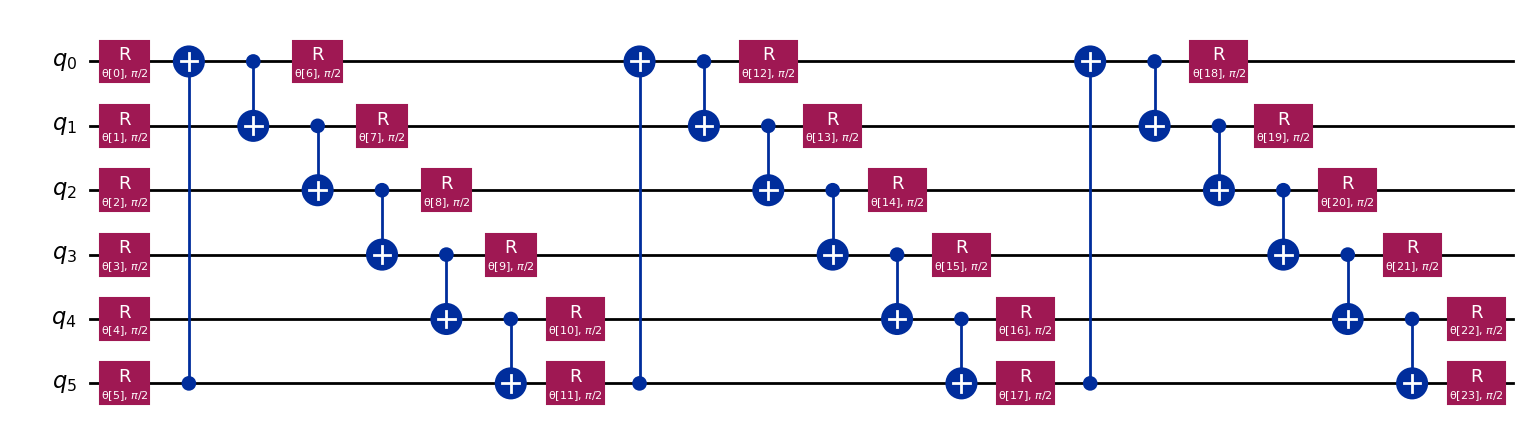

In [8]:
# Now, lets create our ansatz circuit. In this case I use a variation of the hardware efficient Ansatz (HEA), specifically, qiskit's efficient_su2
from qiskit_algorithms.minimum_eigensolvers import AdaptVQE
from qiskit.circuit.library import EvolvedOperatorAnsatz

n = pauli_op.num_qubits
layers = 3
ansatz = qiskit.circuit.library.efficient_su2(n, su2_gates=["ry"], entanglement="circular",reps=layers)
# ansatz = EvolvedOperatorAnsatz(name="Ansatz_Adapt",reps=10)
# num_params = ansatz.num_parameters
# print(f"This ansatz has {num_params} parameters.")
ansatz.decompose().draw("mpl",style="iqp")

Now we can run our circuit and attempt to converge on the ground state energy of the PauliSum.

In [9]:
from qiskit_algorithms.optimizers import COBYLA
# Define Simulation
iterations = 1000
cobyla = COBYLA(maxiter=1000)
counts = []
values = []

def store_intermediate_result(eval_count,parameters,mean,std):
    counts.append(eval_count)
    values.append(mean)

In [10]:
from qiskit_algorithms.utils import algorithm_globals
from qiskit_aer.primitives import EstimatorV2 as AerEstimator

seed = 170
algorithm_globals.random_seed = seed

noiseless_estimator = AerEstimator(options={"default_precision": 1e-2})


In [11]:
from qiskit_algorithms import VQE
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms.optimizers import SLSQP

vqe = VQE(estimator=noiseless_estimator,ansatz=ansatz,optimizer=cobyla,callback=store_intermediate_result)

result = vqe.compute_minimum_eigenvalue(operator=pauli_op)

print(result.eigenvalue)
print(lowest)

-0.12051244732218547
-0.31372745340211067


In [78]:
# Use Qiskit Nature to generate operator pools
from qiskit_nature.second_q.circuit.library import UCC
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import SlaterDeterminant

test = SlaterDeterminant(hamiltonian_matrix)

# num_particles = (1,0)
# test_ansatz = UCC(num_spatial_orbitals=num_sites//2,num_particles=num_particles,qubit_mapper=JordanWignerMapper(),excitations="sd",alpha_spin=True,beta_spin=False)

# # Extract operators:
# operator_pool = list(test_ansatz.operators) 
# print(operator_pool)

ValueError: transformation_matrix must have orthonormal rows.

ADAPT-VQE testing

In [ ]:
from qiskit.quantum_info import SparsePauliOp
vqe = VQE(estimator=noiseless_estimator, ansatz=None,optimizer=cobyla,callback=store_intermediate_result)

# Create our single-qubit building blocks for ADAPT-VQE to build off of
# operator = SparsePauliOp()

# Lets visualize all the operators we create!
operator_list = list()
def all_single_qubit_operators(num_qubits:int):
    for i in range(num_qubits):
        for term in ["X","Y","Z"]:
            init_str = ["I"] * num_qubits # Start with a blank dimensionally-consistent operator
            # Create an operator variation
            init_str[i] = term

            # All to test list
            #test_list.append("".join(init_str))

            # # Convert to SparsePauliOp object and append to list
            # operator_list.append(SparsePauliOp("".join(init_str)))
            final_list.append(SparsePauliOp("".join(init_str)))

# We already defined combined qubit operators!
def all_entangled_qubit_operators(str_list:list,coef_list:list):
    for term1,term2 in zip(str_list,coef_list):
        operator_list.append(SparsePauliOp(data=term1,coeffs=term2))
    

all_single_qubit_operators(n)
all_entangled_qubit_operators(multi_qubit_operator,coef_list)

adapt_vqe = AdaptVQE(solver=vqe,operators=operator_pool,max_iterations=50)

results = adapt_vqe.compute_minimum_eigenvalue(pauli_op)
print(f"Final Result: {results.eigenvalue}")
print(f"Error? : {results.termination_criterion}")
print(f"Iteration count: {results.num_iterations}")
print(f"Actual Result: {lowest}")
print(results.optimal_circuit.draw())
# print(adapt_vqe.get('optimal_circuit').draw("mpl"))
# eigenvalue, _ = adapt_vqe.compute_minimum_eigenvalue(pauli_op)

Final Result: -0.13579296301526006
Error? : TerminationCriterion.CYCLICITY
Iteration count: 2
Actual Result: -0.31372745340211067
     ┌────┐     ┌───┐┌──────────┐┌───┐┌──────┐┌───┐           ┌───┐»
q_0: ┤ √X ├─────┤ X ├┤ Rz(t[0]) ├┤ X ├┤ √Xdg ├┤ H ├───────────┤ X ├»
     └────┘┌───┐└─┬─┘└──────────┘└─┬─┘└┬───┬─┘└───┘      ┌───┐└─┬─┘»
q_1: ──────┤ X ├──■────────────────■───┤ X ├─────────────┤ X ├──■──»
     ┌───┐ └─┬─┘                       └─┬─┘  ┌───┐┌────┐└─┬─┘     »
q_2: ┤ H ├───■───────────────────────────■────┤ H ├┤ √X ├──■───────»
     └───┘                                    └───┘└────┘          »
q_3: ──────────────────────────────────────────────────────────────»
                                                                   »
q_4: ──────────────────────────────────────────────────────────────»
                                                                   »
q_5: ──────────────────────────────────────────────────────────────»
                                          